<a href="https://colab.research.google.com/github/feronika-lab/What-Drives-Health-Insurance-Costs-A-Data-Analysis-of-Risk-Factors/blob/main/Forecasting_Health_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset : **profil kesehatan dari 1.338 individu di Amerika Serikat**. <br><br>


**Risk Factors/Risk Variables**:

-usia (age)

-indeks massa tubuh atau BMI (Body Mass Index)

-status merokok (smoker)

-jumlah tanggungan (children)

-wilayah tempat tinggal (region)

terhadap **total biaya medis (charges)** yang ditanggung oleh perusahaan asuransi (besaran klaim kesehatan).
<br><br>


**Penggunaan Machine Learning**

Digunakan untuk membandingkan performa model seperti:

Random Forest, Gradient Boosting, XGBoost <br><br>


**Analis Data**

Dataset ini dapat digunakan untuk menjawab pertanyaan analitis seperti:

-Apakah perokok memiliki biaya klaim lebih tinggi dibandingkan non-perokok?

-Seberapa besar pengaruh BMI terhadap biaya medis?

-Apakah terdapat perbedaan biaya antar wilayah?


# **1. Import Library**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as pt
import warnings
warnings.filterwarnings("ignore")

# **2. Load Data**

In [ ]:
url = "https://raw.githubusercontent.com/bencmbit/datasets/master/insurance.csv"
df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# **3. Cek kualitas data (pre-EDA)**

### 3.1. Data Summary

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### 3.2 Descriptive Statistics

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Age

- Usia peserta berkisar antara 18(produktif) hingga 64(lanjut) tahun.

- Rata-rata usia adalah sekitar 39 tahun, dengan median 39 tahun, menunjukkan distribusi usia yang relatif seimbang.

- Rentang usia ini mencerminkan populasi usia produktif hingga mendekati usia lanjut (distribusi lebar), yang berpotensi memiliki tingkat risiko kesehatan yang berbeda (variasi).

BMI (Body Mass Index)

- Menurut standar World Health Organization (WHO), kategori BMI secara umum adalah:

  - BMI < 18.5 → Underweight (berat badan kurang)

  - BMI 18.5 – 24.9 → Normal

  - BMI 25 – 29.9 → Overweight

  - BMI ≥ 30 → Obese (obesitas)

- Nilai BMI pada data berkisar antara 15.96 hingga 53.13.

- Rata-rata BMI adalah sekitar 30.66, yang berada pada kategori obesitas ringan.

Children

- Jumlah tanggungan berkisar antara 0 hingga 5 anak.

- Nilai rata-rata sekitar 1 anak per individu.

- Median sebesar 1 anak, menunjukkan bahwa sebagian besar individu memiliki jumlah anak yang relatif sedikit.

- Sekitar 75% individu memiliki maksimal 2 anak.

Charges

- Biaya asuransi kesehatan berkisar antara 1,121 hingga 63,770.

- Rata-rata biaya adalah sekitar 13,270, dengan median sekitar 9,382 (lebih rendah).

- Perbedaan yang cukup besar antara nilai minimum dan maksimum menunjukkan distribusi right-skewed (adanya outlier biaya yang sangat tinggi).

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


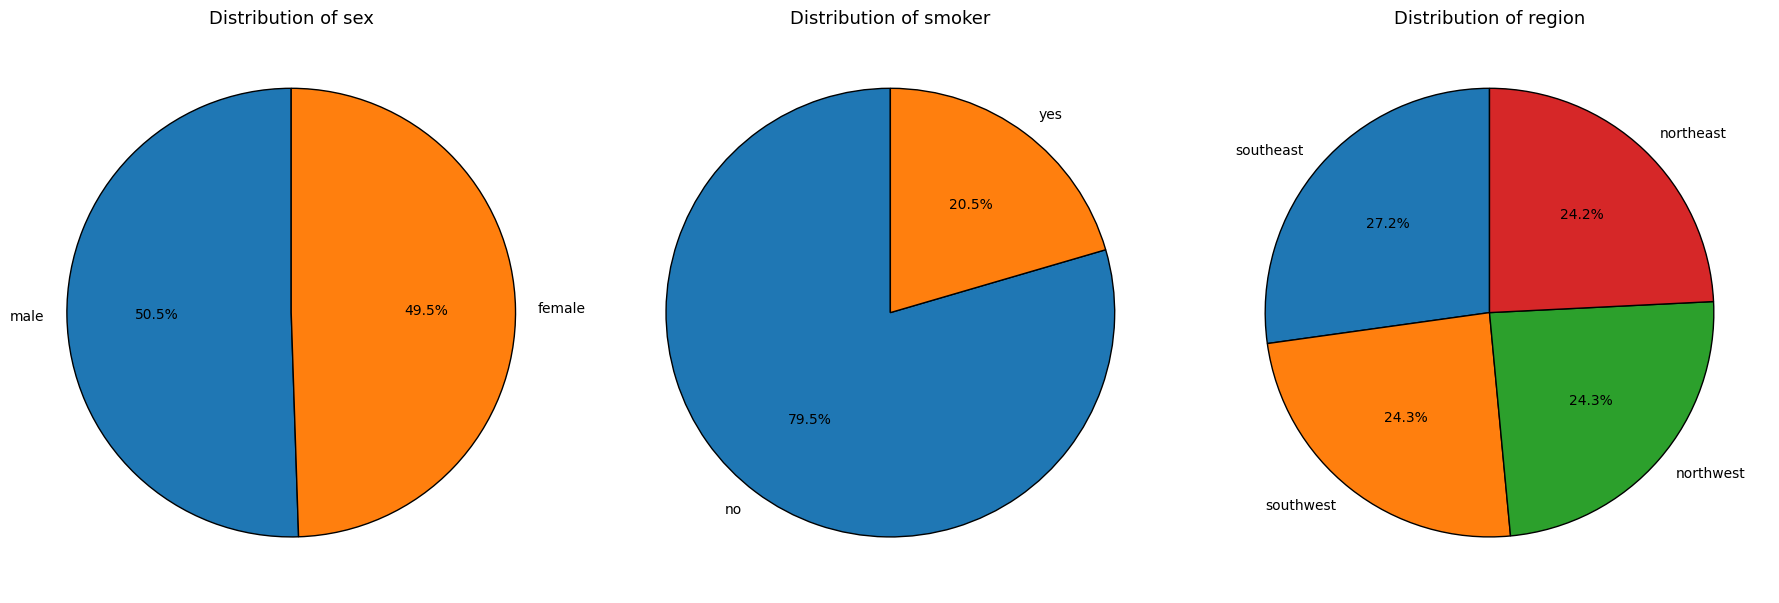

In [ ]:
import matplotlib.pyplot as plt

features = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(features):

    counts = df[col].value_counts()

    axes[i].pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'black'}
    )

    axes[i].set_title(f'Distribution of {col}', fontsize=13)

plt.tight_layout()
plt.show()

1. Gender

    - Distribusi gender sangat seimbang (male 50.5%, female 49.5%).

    - Dataset tidak memiliki gender bias, sehingga perbedaan biaya asuransi nantinya lebih mungkin dijelaskan oleh faktor risiko lain seperti BMI, smoking status, atau age.

    - Variabel sex kemungkinan bukan driver utama charges, tetapi tetap relevan untuk melihat apakah terdapat perbedaan pola biaya kesehatan antar gender.

2. Smoker

    - Sekitar 79.5% individu adalah non-smoker, sedangkan 20.5% adalah smoker.

    - Meskipun proporsi smoker kecil, dalam konteks asuransi kesehatan kelompok ini sering menjadi penyumbang biaya medis terbesar.

    - Hal ini menunjukkan potensi risk segmentation, dimana perusahaan asuransi dapat membedakan pricing antara smoker dan non-smoker.

    - Variabel smoker kemungkinan menjadi salah satu faktor paling signifikan dalam menjelaskan variasi charges.

3. Region

    - Dataset mencakup empat wilayah dengan distribusi yang relatif merata (sekitar 24–27%).

    - Tidak ada wilayah yang terlalu dominan, sehingga analisis biaya antar region dapat dilakukan tanpa bias distribusi sampel.

    - Jika ditemukan perbedaan charges antar region, kemungkinan disebabkan oleh faktor regional seperti biaya layanan kesehatan, gaya hidup, atau akses fasilitas kesehatan, bukan karena ketidakseimbangan data.

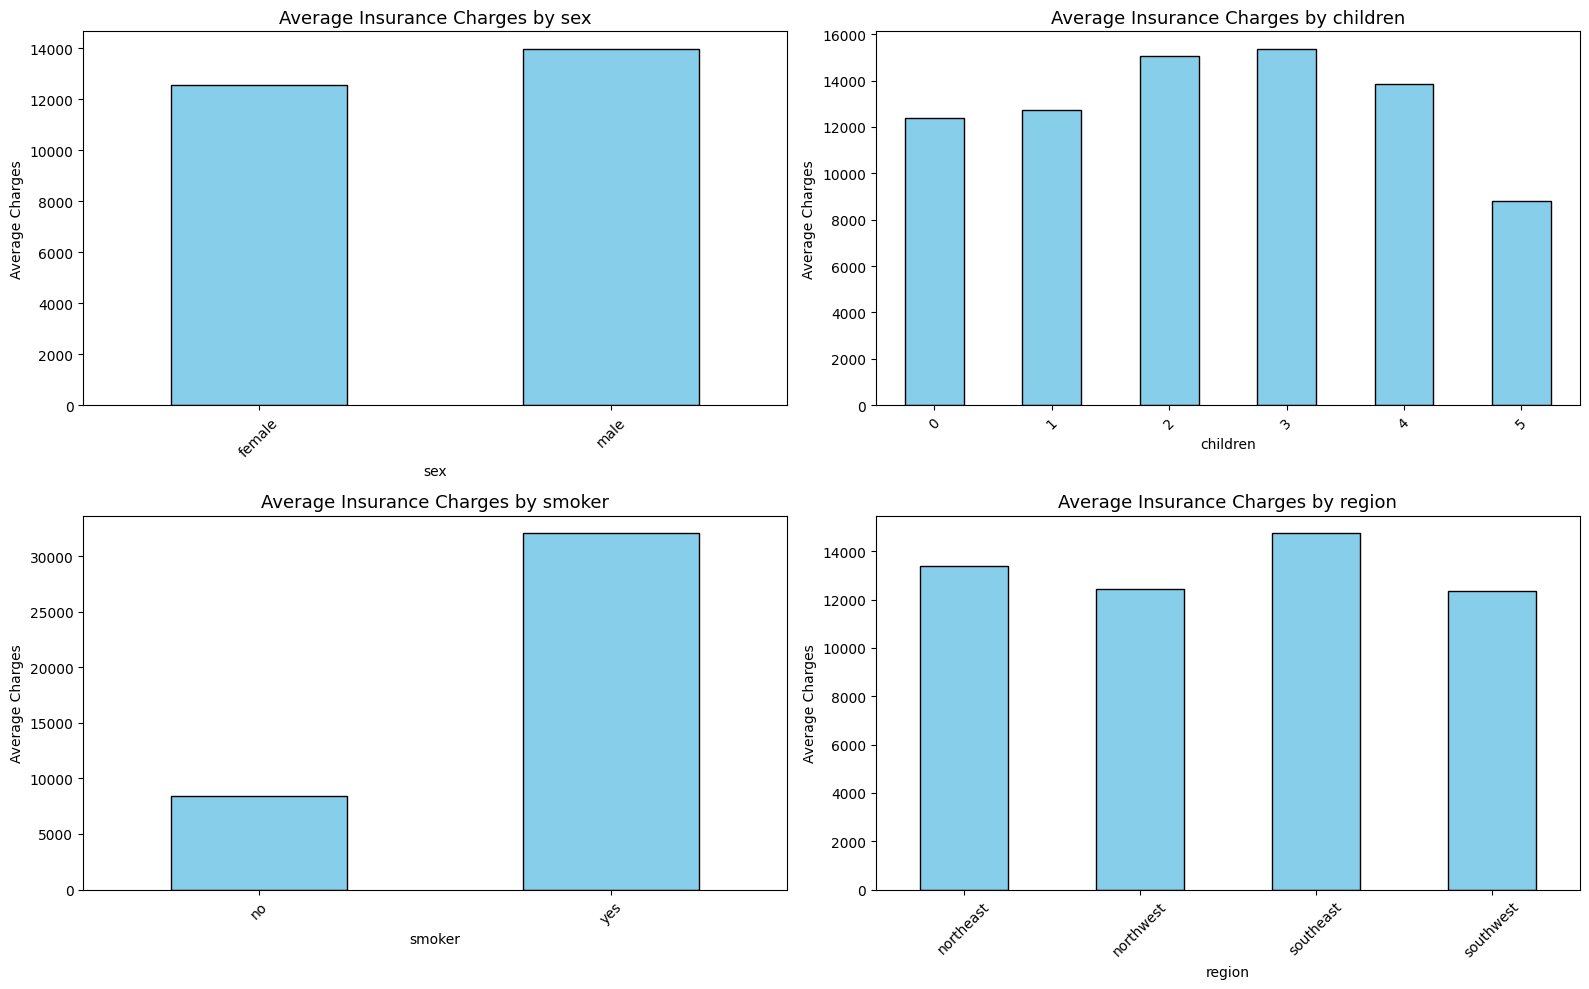

In [ ]:
import matplotlib.pyplot as plt

features = ['sex', 'children', 'smoker', 'region']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):

    avg_charges = df.groupby(col)['charges'].mean().astype(float)

    avg_charges.plot(
        kind='bar',
        ax=axes[i],
        color='skyblue',
        edgecolor='black'
    )

    axes[i].set_title(f'Average Insurance Charges by {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Average Charges')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

1. Average Charges by Sex

    - Male memiliki rata-rata biaya sedikit lebih tinggi (~14k) dibanding female (~12.5k).

    - Namun perbedaannya tidak terlalu signifikan, sehingga gender kemungkinan bukan faktor utama yang mendorong variasi biaya asuransi,tetapi faktor kesehatan atau gaya hidup kemungkinan lebih berpengaruh dibanding gender dalam menentukan biaya medis.

2. Average Charges by Children

    - Rata-rata biaya meningkat dari 0 hingga 3 anak, dengan puncak biaya pada 3 tanggungan.

    - Setelah itu, biaya tidak terus meningkat secara konsisten (misalnya pada 4 dan 5 anak justru menurun).

    - Pola ini menunjukkan bahwa jumlah tanggungan tidak memiliki hubungan linear yang kuat dengan biaya asuransi.


3. Average Charges by Smoker

    - Perbedaan biaya antara smoker dan non-smoker sangat besar. Dengan rata-rata biaya smoker sekitar 3–4 kali lebih tinggi dibanding non-smoker.

    - Hal ini menunjukkan bahwa status merokok merupakan salah satu faktor risiko   paling signifikan dalam menentukan biaya asuransi kesehatan (risk rating factor)

4. Average Charges by Region

    - Biaya rata-rata antar wilayah relatif mirip, dengan southeast memiliki rata-rata biaya tertinggi, sementara wilayah lain cukup berdekatan.

    - Hal ini menunjukkan bahwa lokasi geografis mungkin memiliki pengaruh moderat terhadap biaya medis, tetapi tidak sekuat faktor risiko individu seperti smoking status.

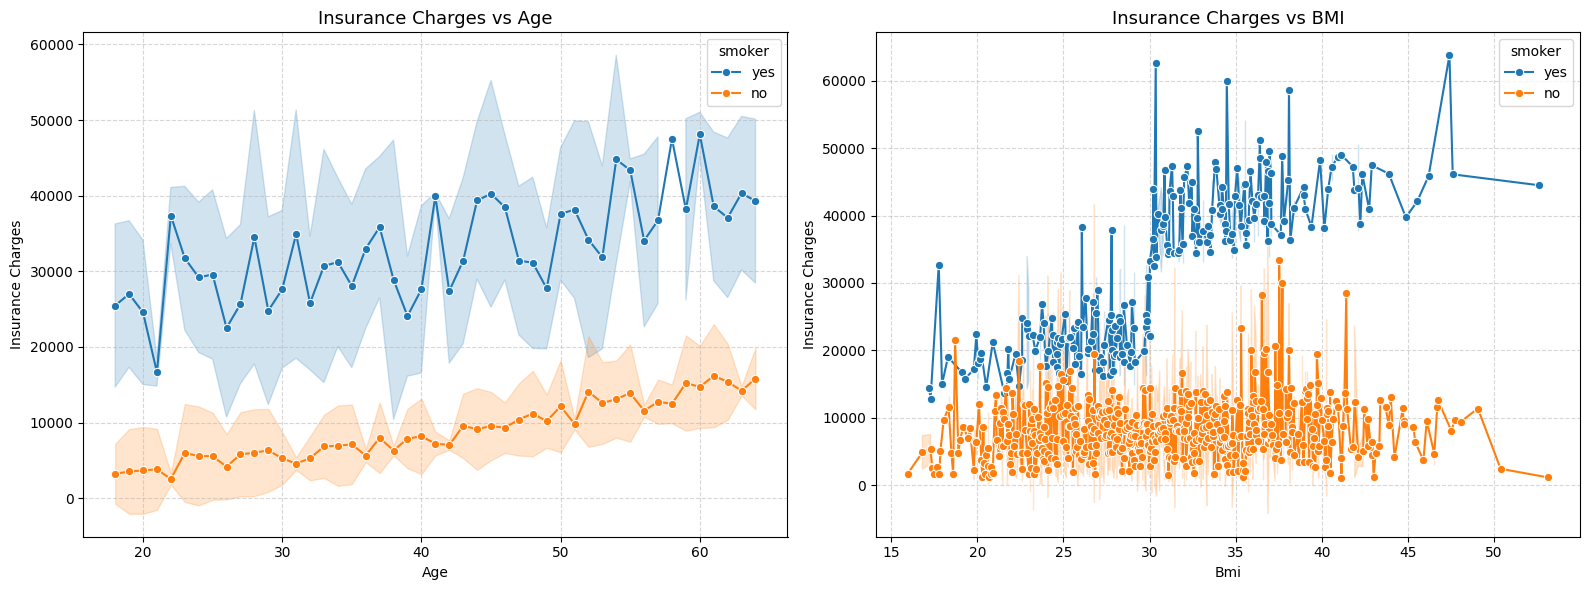

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['age', 'bmi']
titles = ['Insurance Charges vs Age', 'Insurance Charges vs BMI']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(features):

    sns.lineplot(
        data=df,
        x=col,
        y='charges',
        hue='smoker',
        estimator='mean',
        errorbar='sd',
        marker='o',
        ax=axes[i]
    )

    axes[i].set_title(titles[i], fontsize=13)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Insurance Charges')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Insurance Charges vs Age

1. Efek Usia Lebih Kuat pada Kelompok Smoker

    - Pada kelompok non-smoker, kenaikan biaya seiring usia terlihat relatif gradual dan stabil.

    - Pada kelompok smoker, kenaikan biaya terlihat lebih curam.

    - Usia memperbesar dampak risiko merokok terhadap biaya medis.

2. Variasi Biaya pada Smoker Sangat Tinggi

    - Pada kelompok smoker, terdapat rentang biaya yang sangat lebar pada usia yang sama. Contohnya pada usia sekitar 30–40 tahun, biaya dapat berkisar dari sekitar 20k hingga lebih dari 40k.

    - Ini menunjukkan bahwa: smoker kemungkinan memiliki komorbiditas tambahan (misalnya BMI tinggi atau kondisi kesehatan lain). Artinya smoking bukan satu-satunya driver biaya tinggi.

3. Indikasi Heteroskedastisitas

    - Variansi biaya terlihat semakin besar pada usia yang lebih tinggi, terutama pada kelompok smoker. Hal ini menunjukkan bahwa ketidakpastian biaya medis meningkat seiring bertambahnya usia.
    - kemungkinan error variance tidak konstan.

4. Ada Smoker Muda dengan Biaya Sangat Tinggi

    - Beberapa individu usia muda (~25–30 tahun) yang sudah memiliki biaya medis sangat tinggi.

    - Hal ini bisa mengindikasikan: kondisi kesehatan serius, BMI sangat tinggi, atau faktor risiko lain.

    - Ini menunjukkan bahwa risiko biaya tinggi tidak hanya muncul pada usia tua.

5. Gap Biaya Tidak Linear Sepanjang Usia

    - Risiko merokok bersifat kumulatif terhadap usia yang ditunjukkan pada usia muda gap sudah besar. Namun pada usia 40+ gap menjadi jauh lebih ekstrem.

## Deteksi outlier (fokus: age dan bmi)

<Axes: ylabel='age'>

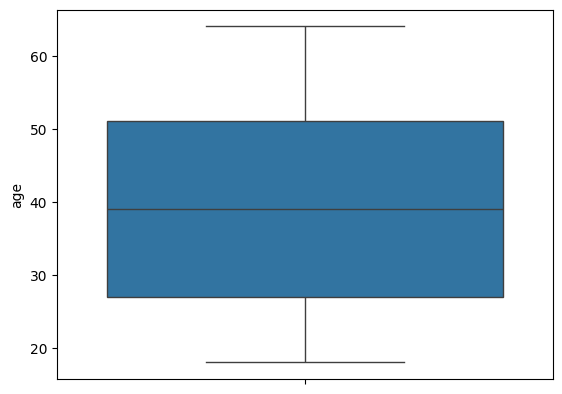

In [ ]:
df.drop_duplicates(inplace=True)
sns.boxplot(df['age'])

<Axes: ylabel='bmi'>

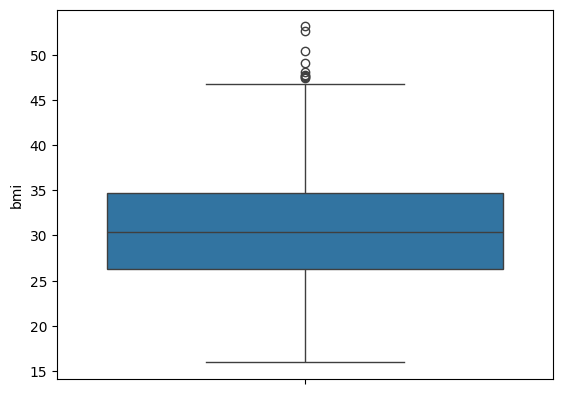

In [ ]:
sns.boxplot(df['bmi'])

In [ ]:
Q1=df['bmi'].quantile(0.25)
print(Q1)
Q2=df['bmi'].quantile(0.5)
print (Q2)
Q3=df['bmi'].quantile(0.75)
print(Q3)
iqr=Q3-Q1
print(iqr)
lowlim=Q1-1.5*iqr
upplim=Q3+1.5*iqr
print(lowlim)
print(upplim)

26.29
30.4
34.7
8.410000000000004
13.674999999999994
47.31500000000001


In [ ]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


Menggunakan Pandas .clip() (Paling Simpel)

Metode ini adalah cara yang paling "Pythonic" dan bersih jika kamu sudah menggunakan DataFrame. Fungsi clip secara otomatis menahan nilai di bawah lower bound dan di atas upper bound.

Setiap nilai di kolom bmi yang lebih kecil dari 13.6749 akan diubah menjadi 13.6749.

Setiap nilai yang lebih besar dari 47.315 akan diubah menjadi 47.315.

Nilai di antaranya tetap tidak berubah.

<Axes: xlabel='bmi'>

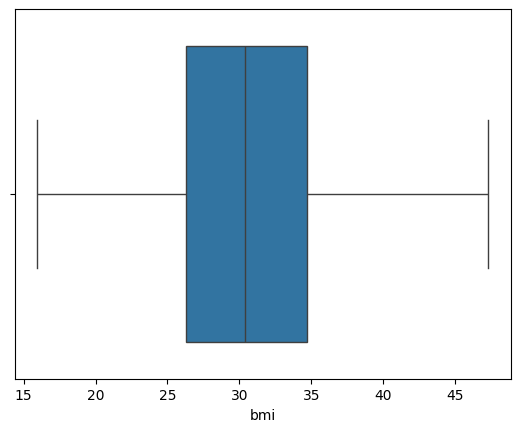

In [ ]:
import seaborn as sns

# Melakukan 'capping' nilai bmi (batas bawah 13.6749 dan batas atas 47.315)
# lalu langsung menampilkannya dalam boxplot
df['bmi'] = df['bmi'].clip(lower=13.6749, upper=47.315)

sns.boxplot(x=df['bmi'])


In [ ]:
print(df['bmi'].describe())

count    1337.000000
mean       30.650247
std         6.059655
min        15.960000
25%        26.290000
50%        30.400000
75%        34.700000
max        47.315000
Name: bmi, dtype: float64


Perintah .skew() dalam Pandas digunakan untuk mengukur kemiringan (asimetri) dari distribusi data kamu. Nilai ini sangat penting untuk menentukan apakah data kamu terdistribusi normal atau "berat sebelah". Nilai Skewness : -0.5 s/d 0.5	Data Simetris (Sangat bagus/Normal).

In [ ]:
df['bmi'].skew()
df['age'].skew()

np.float64(0.054780773126998195)

0.054, data ini berada sangat dekat dengan angka 0. Artinya, baik bmi maupun age memiliki distribusi yang sangat seimbang. Tidak ada "ekor" yang terlalu panjang yang menarik rata-rata ke salah satu sisi secara signifikan.

In [ ]:
# Menggabungkan semua pemetaan ke dalam satu dictionary
mapping = {
    'sex': {'male': 0, 'female': 1},
    'smoker': {'yes': 1, 'no': 0},
    'region': {'northwest': 0, 'northeast': 1, 'southeast': 2, 'southwest': 3}
}

# Menerapkan perubahan sekaligus ke seluruh DataFrame
df.replace(mapping, inplace=True)

Mesin Korelasi Hanya Mengenal Angka, maka perlu melakukan Label Encoding atau Mapping, dan ini adalah persiapan wajib sebelum membuat Correlation Heatmap.

In [ ]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,0.019814,0.111998,0.041536,-0.025587,0.001771,0.298308
sex,0.019814,1.000000,-0.044831,-0.017848,-0.076596,-0.008998,-0.058044
bmi,0.111998,-0.044831,1.000000,0.013692,0.003151,0.156937,0.199063
children,0.041536,-0.017848,0.013692,1.000000,0.007331,-0.002842,0.067389
smoker,-0.025587,-0.076596,0.003151,0.007331,1.000000,0.012736,0.787234
region,0.001771,-0.008998,0.156937,-0.002842,0.012736,1.000000,0.010767
charges,0.298308,-0.058044,0.199063,0.067389,0.787234,0.010767,1.000000


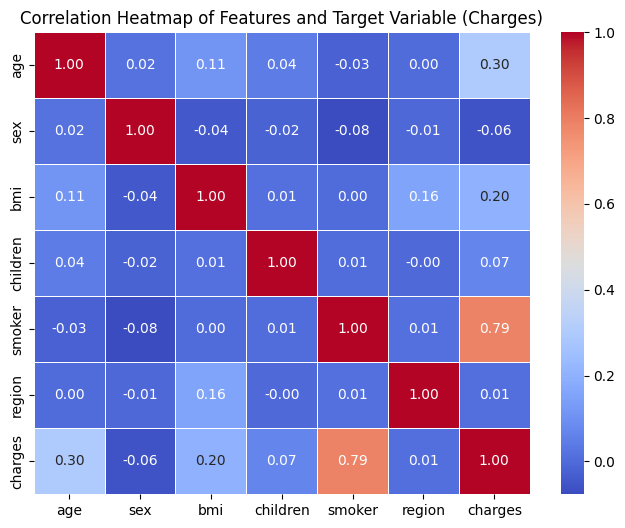

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Menggunakan plt.subplots() agar lebih fleksibel (OO Style)
fig, ax = plt.subplots(figsize=(8, 6))

# Memasukkan df.corr() langsung ke dalam heatmap untuk menyingkat baris
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax)

# Mengatur judul melalui objek 'ax'
ax.set_title("Correlation Heatmap of Features and Target Variable (Charges)")

plt.show()


## Pembuatan Model dan Pengujian

**Linear Regression**

Script ini bertujuan untuk menguji stabilitas model **Linear Regression**. Dengan menjalankan model berkali-kali pada pembagian data yang berbeda, kamu bisa melihat apakah performa modelmu konsisten atau sangat bergantung pada cara data dibagi.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score

# 1. Penyiapan Fitur dan Target
X = df.drop(['charges'], axis=1)
y = df['charges']

# 2. Inisialisasi list untuk menampung hasil
results = []

# 3. Loop untuk menguji stabilitas model pada berbagai random_state
for i in range(40, 50):
    # Split data
    xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=i)

    # Inisialisasi dan Training Model
    lrmodel = LinearRegression()
    lrmodel.fit(xtrain, ytrain)

    # Perhitungan Skor
    train_score = lrmodel.score(xtrain, ytrain)
    test_score = lrmodel.score(xtest, ytest)
    cv_mean = cross_val_score(lrmodel, X, y, cv=5).mean()

    # Menyimpan hasil ke dalam list of dictionaries
    results.append({
        'train acc': train_score,
        'test acc': test_score,
        'cvs': cv_mean
    })

# 4. Membuat DataFrame akhir
df1 = pd.DataFrame(results)
df1


,train acc,test acc,cvs
0,0.741659,0.778409,0.74707
1,0.756401,0.706267,0.74707
2,0.729542,0.806239,0.74707
3,0.754260,0.732791,0.74707
4,0.742966,0.779591,0.74707
5,0.753281,0.731769,0.74707
6,0.741261,0.776456,0.74707
7,0.731940,0.796173,0.74707
8,0.751915,0.741742,0.74707
9,0.756348,0.722565,0.74707


Script ini adalah alur kerja (workflow) standar dalam machine learning untuk melatih, menguji, dan memvalidasi model regresi. Berikut adalah penjelasan detail setiap langkahnya:

In [ ]:
# 1. Pembagian Data (Train-Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Inisialisasi dan Pelatihan Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 3. Kalkulasi Skor Akurasi
train_score = lr_model.score(X_train, y_train)
test_score = lr_model.score(X_test, y_test)
cv_score = cross_val_score(lr_model, X, y, cv=5).mean()

# 4. Menampilkan Hasil dengan Format yang Rapi
print(f"Training Accuracy: {train_score:.4f}")
print(f"Testing Accuracy:  {test_score:.4f}")
print(f"Cross-Val Score:   {cv_score:.4f}")

Training Accuracy: 0.7295
Testing Accuracy:  0.8062
Cross-Val Score:   0.7471


| Evaluasi Model         | Nilai R²   | Interpretasi                                                        |
| ---------------------- | ---------- | ------------------------------------------------------------------- |
| Training Accuracy      | **0.7295** | Model mampu menjelaskan sekitar **72.95% variasi data training**    |
| Testing Accuracy       | **0.8062** | Model mampu menjelaskan sekitar **80.62% variasi data testing / data baru dengan benar**     |
| Cross Validation Score | **0.7471** | Rata-rata kemampuan model / Performa rata rata model pada **5-fold validation sekitar 74.71%** |





Apakah Model Ini Bagus?

Ada hal menarik dari hasilmu: Test Score (0.806) lebih tinggi daripada Train Score (0.729).

    Kabar Baik: Model kamu tidak mengalami overfitting (tidak sekadar menghafal).

    Analisis: Biasanya Train Score sedikit lebih tinggi. Jika Test Score jauh lebih tinggi, itu artinya kamu "beruntung" mendapatkan data uji yang polanya lebih sederhana. Namun, nilai CVS (0.747) memberikan angka yang lebih jujur, yaitu performa aslimu ada di angka 75%.

Untuk model Linear Regression pada data asuransi, skor 75% sudah tergolong cukup baik, tapi masih bisa ditingkatkan karena biaya medis seringkali memiliki hubungan yang tidak garis lurus (non-linear).

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score

# 1. Inisialisasi & Pelatihan Model Dasar (Base Model)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(xtrain, ytrain)

# Menampilkan Skor Dasar (Menggunakan .score() untuk R2 yang identik)
print(rf_model.score(xtrain, ytrain))
print(rf_model.score(xtest, ytest))
print(cross_val_score(rf_model, X, y, cv=5).mean())

# 2. Hyperparameter Tuning menggunakan GridSearchCV
param_grid = {'n_estimators': [10, 40, 50, 98, 100, 120, 150]}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, scoring="r2", cv=5)
grid_search.fit(xtrain, ytrain)

print(grid_search.best_params_)

# 3. Final Model dengan Parameter Terbaik (n_estimators=120)
# Kita langsung menggunakan model terbaik dari hasil grid_search
final_rf = grid_search.best_estimator_

# Menampilkan Skor Akhir
print(final_rf.score(xtrain, ytrain))
print(final_rf.score(xtest, ytest))
print(cross_val_score(final_rf, X, y, cv=5).mean())

0.9762925493818944
0.8535472723881479
0.8363637309718952
{'n_estimators': 50}
0.9757601410966716
0.8525322549085311
0.8343968433366324


1. Hasil Evaluasi Model Random Forest

| Evaluasi Model         | Nilai R²   | Interpretasi                                                       |
| ---------------------- | ---------- | ------------------------------------------------------------------ |
| Training Accuracy      | **0.9763** | Model mampu menjelaskan sekitar **97.63% variasi data training** model hampir sempurna memetakan pola data latihan  |
| Testing Accuracy       | **0.8535** | Model mampu menjelaskan sekitar **85.35% variasi data testing** Model kamu sangat akurat dalam memprediksi data baru yang belum pernah dilihat sebelumnya (akurasi 85%)   |
| Cross Validation Score | **0.8364** | Rata-rata performa model pada **5-fold validation sekitar 83.64%** stabil, membuktikan hassil bukan kebetulan (objectiv) |

2. Hasil Hyperparameter Tuning

Grid Search menghasilkan parameter terbaik:
| Parameter    | Nilai Terbaik | Fungsi                                            |
| ------------ | ------------- | ------------------------------------------------- |
| n_estimators | **50**        | Jumlah pohon (decision trees) dalam Random Forest |

Setelah model dilatih kembali dengan parameter terbaik, diperoleh hasil:

| Model                | Parameter         | Training R² | Testing R² | Cross Validation |
| -------------------- | ----------------- | ----------- | ---------- | ---------------- |
| Random Forest awal   | default           | 0.9763      | **0.8535** | 0.8364           |
| Random Forest tuning | n_estimators = 50 | 0.9758      | **0.8525** | 0.8344           |

Penyebab Kenapa Akurasi Tidak Naik : Parameter tuning tidak selalu meningkatkan performa

Pada Random Forest, menambah atau memilih jumlah tree terbaik tidak selalu meningkatkan akurasi.

Karena:

model default sudah cukup optimal
dataset mungkin tidak membutuhkan banyak tree.


3. Insight dari Hasil Model

1️⃣ Model sangat baik pada data training

Nilai training: 0.975

Artinya model mampu menjelaskan lebih dari 97% variasi data training.

Ini menunjukkan bahwa Random Forest sangat kuat dalam mempelajari pola data.

2️⃣ Performa model pada data testing tetap tinggi

Testing score: 0.852

Artinya model masih mampu menjelaskan sekitar 85% variasi data baru.

Ini menunjukkan model memiliki kemampuan prediksi yang baik.

3️⃣ Terdapat sedikit indikasi overfitting

Meskipun skornya tinggi, ada selisih yang cukup besar antara Train (97%) dan Test (85%). Selisih sekitar 12% ini menandakan adanya Overfitting.

  Artinya: Model kamu sedikit "menghafal" detail-detail kecil atau noise pada data latihan, sehingga ketika bertemu data baru (Test), ia sedikit bingung dan akurasinya turun.

  Visualisasi: Bayangkan seorang siswa yang menghafal soal latihan ujian. Saat ujian asli keluar dengan angka yang sedikit berbeda, ia masih bisa menjawab dengan baik (85%), tapi tidak sehebat saat latihan (97%).

4️⃣ Cross-validation mendekati hasil testing

Cross validation: 0.836

| Evaluasi         | Nilai |
| ---------------- | ----- |
| Testing          | 0.852 |
| Cross Validation | 0.834 |

Perbedaannya kecil (~0.02). Artinya model cukup stabil dan konsisten pada berbagai pembagian data.

4. Kesimpulan

Testing accuracy sedikit turun karena:

- Random Forest memiliki unsur randomness

- Parameter tuning tidak selalu meningkatkan test accuracy

- Dataset sudah mendekati batas performa model

- Perbedaan 0.001 sangat kecil dan tidak signifikan

Sehingga model dengan n_estimators = 50 tetap valid digunakan.



**GradientBoostingRegressor**

dari library scikit-learn. Model ini bekerja dengan metode boosting, yaitu membangun beberapa model decision tree secara bertahap, dimana setiap model baru memperbaiki kesalahan model sebelumnya.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score

# 1. Inisialisasi & Pelatihan Model Dasar (Base Model)
gb_model = GradientBoostingRegressor()
gb_model.fit(xtrain, ytrain)

# Menampilkan Skor Dasar menggunakan .score()
print(gb_model.score(xtrain, ytrain))
print(gb_model.score(xtest, ytest))
print(cross_val_score(gb_model, X, y, cv=5).mean())

# 2. Hyperparameter Tuning (Mencari Kombinasi Terbaik)
param_grid = {
    'n_estimators': [10, 15, 19, 20, 21, 50],
    'learning_rate': [0.1, 0.19, 0.2, 0.21, 0.8, 1]
}

grid_search = GridSearchCV(GradientBoostingRegressor(), param_grid, scoring="r2", cv=5)
grid_search.fit(xtrain, ytrain)

print(grid_search.best_params_)

# 3. Mengambil Model Terbaik secara Otomatis
# Tidak perlu mengetik ulang n_estimators=19 secara manual
final_gb = grid_search.best_estimator_

# Menampilkan Skor Akhir
print(final_gb.score(xtrain, ytrain))
print(final_gb.score(xtest, ytest))
print(cross_val_score(final_gb, X, y, cv=5).mean())

0.8988766039341503
0.8638994273966534
0.855035383181748
{'learning_rate': 0.19, 'n_estimators': 21}
0.880268912226411
0.8668378509681596
0.8599526639982077


1. Hasil Evaluasi Model

Sebelum Hyperparameter Tuning

| Evaluasi Model         | Nilai R²   | Interpretasi                                                       |
| ---------------------- | ---------- | ------------------------------------------------------------------ |
| Training Accuracy      | **0.8989** | Model mampu menjelaskan sekitar **89.89% variasi data training**   |
| Testing Accuracy       | **0.8639** | Model mampu menjelaskan sekitar **86.39% variasi data testing**    |
| Cross Validation Score | **0.8551** | Rata-rata performa model pada **5-fold validation sekitar 85.51%** |

Parameter Terbaik dari Hyperparameter Tuning

| Parameter     | Nilai Terbaik | Fungsi                                           |
| ------------- | ------------- | ------------------------------------------------ |
| learning_rate | **0.19**      | Mengontrol seberapa besar kontribusi setiap tree |
| n_estimators  | **21**        | Jumlah tree yang digunakan dalam boosting        |


Setelah Hyperparameter Tuning

| Evaluasi Model         | Nilai R²   | Interpretasi                                               |
| ---------------------- | ---------- | ---------------------------------------------------------- |
| Training Accuracy      | **0.8803** | Model menjelaskan sekitar **88.03% variasi data training** |
| Testing Accuracy       | **0.8668** | Model menjelaskan sekitar **86.68% variasi data testing**  |
| Cross Validation Score | **0.8600** | Rata-rata performa model sekitar **86.00%**                |


2. Perbandingan Sebelum dan Sesudah Tuning

| Evaluasi         | Sebelum Tuning | Setelah Tuning | Perubahan     |
| ---------------- | -------------- | -------------- | ------------- |
| Training R²      | 0.8989         | 0.8803         | sedikit turun |
| Testing R²       | 0.8639         | **0.8668**     | sedikit naik  |
| Cross Validation | 0.8551         | **0.8600**     | meningkat     |


3. Insight dari Model


1️⃣ Model memiliki performa prediksi yang baik

Nilai R² pada data testing sekitar 0.86, artinya model mampu menjelaskan sekitar 86% variasi data target.

Ini menunjukkan bahwa Gradient Boosting memiliki kemampuan prediksi yang kuat.

2️⃣ Hyperparameter tuning meningkatkan generalisasi model

Setelah tuning:

training score sedikit menurun

testing dan cross-validation meningkat

Ini menandakan bahwa model menjadi lebih generalizable.

Artinya model:

✔ lebih stabil
✔ lebih baik dalam memprediksi data baru.

3️⃣ Tidak terjadi overfitting yang signifikan

Perbandingan nilai:

| Dataset  | R²    |
| -------- | ----- |
| Training | 0.880 |
| Testing  | 0.867 |

Selisih hanya sekitar:

0.013

Perbedaan kecil ini menunjukkan:

✔ model tidak overfitting
✔ model cukup seimbang antara training dan testing.

4️⃣ Cross-validation mendukung kestabilan model

Nilai cross-validation:

0.8599

Nilai ini sangat dekat dengan testing score (0.8668), sehingga model:

✔ cukup konsisten
✔ tidak terlalu bergantung pada satu pembagian data.

4. Kesimpulan

| Aspek              | Penilaian                           |
| ------------------ | ----------------------------------- |
| Kualitas Model     | Sangat Baik                         |
| Kemampuan Prediksi | Tinggi (R² ≈ 0.86)                  |
| Overfitting        | Sangat kecil                        |
| Stabilitas Model   | Stabil berdasarkan cross-validation |

Model Gradient Boosting Regressor setelah hyperparameter tuning memberikan performa yang stabil dan akurat, sehingga cocok digunakan sebagai model prediksi pada dataset ini.

**XGBRegressor**

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV

# =============================
# 1. Membuat dan melatih model awal
# =============================
model_xgb = XGBRegressor()

model_xgb.fit(xtrain, ytrain)

# Prediksi
train_pred = model_xgb.predict(xtrain)
test_pred = model_xgb.predict(xtest)

# Evaluasi R2
train_r2 = r2_score(ytrain, train_pred)
test_r2 = r2_score(ytest, test_pred)
cv_r2 = cross_val_score(model_xgb, X, y, cv=5).mean()

print(train_r2)
print(test_r2)
print(cv_r2)

# =============================
# 2. Hyperparameter tuning dengan GridSearch
# =============================
param_grid = {
    'n_estimators': [10, 15, 20, 40, 50],
    'max_depth': [3, 4, 5],
    'gamma': [0, 0.15, 0.3, 0.5, 1]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=param_grid,
    scoring="r2",
    cv=5
)

grid_search.fit(xtrain, ytrain)

print(grid_search.best_params_)

# =============================
# 3. Model terbaik dari GridSearch
# =============================
best_model = XGBRegressor(
    n_estimators=15,
    max_depth=3,
    gamma=0
)

best_model.fit(xtrain, ytrain)

# Prediksi ulang
train_pred_best = best_model.predict(xtrain)
test_pred_best = best_model.predict(xtest)

# Evaluasi ulang
print(r2_score(ytrain, train_pred_best))
print(r2_score(ytest, test_pred_best))
print(cross_val_score(best_model, X, y, cv=5).mean())

0.9945629775107956
0.8017688578963418
0.808125309217053
{'gamma': 0, 'max_depth': 3, 'n_estimators': 10}
0.8808107034989607
0.863695722278562
0.8607115291219747


1. Hasil Evaluasi Model

Sebelum Hyperparameter Tuning

| Evaluasi Model         | Nilai R²   | Interpretasi                                                     |
| ---------------------- | ---------- | ---------------------------------------------------------------- |
| Training Accuracy      | **0.9946** | Model mampu menjelaskan sekitar **99.46% variasi data training** |
| Testing Accuracy       | **0.8018** | Model mampu menjelaskan sekitar **80.18% variasi data testing**  |
| Cross Validation Score | **0.8081** | Rata-rata performa model sekitar **80.81%**                      |


Insight

Training score sangat tinggi.

Testing score jauh lebih rendah.

Ini menunjukkan adanya overfitting, dimana model sangat cocok pada data training tetapi kurang optimal pada data baru.

2. Parameter Terbaik dari Hyperparameter Tuning

Hasil tuning memberikan parameter terbaik:

| Parameter    | Nilai Terbaik | Fungsi                                        |
| ------------ | ------------- | --------------------------------------------- |
| gamma        | **0**         | Mengontrol minimal loss reduction untuk split |
| max_depth    | **3**         | Kedalaman maksimum tree                       |
| n_estimators | **10**        | Jumlah tree dalam model boosting              |

Parameter ini membuat model menjadi lebih sederhana dan tidak terlalu kompleks.


3. Hasil Model Setelah Hyperparameter Tuning

| Evaluasi Model         | Nilai R²   | Interpretasi                                               |
| ---------------------- | ---------- | ---------------------------------------------------------- |
| Training Accuracy      | **0.8808** | Model menjelaskan sekitar **88.08% variasi data training** |
| Testing Accuracy       | **0.8637** | Model menjelaskan sekitar **86.37% variasi data testing**  |
| Cross Validation Score | **0.8607** | Rata-rata performa model sekitar **86.07%**                |


4. Perbandingan Sebelum dan Sesudah Tuning

| Evaluasi         | Sebelum Tuning | Setelah Tuning | Insight                      |
| ---------------- | -------------- | -------------- | ---------------------------- |
| Training R²      | 0.9946         | 0.8808         | Kompleksitas model berkurang |
| Testing R²       | 0.8018         | **0.8637**     | Akurasi meningkat            |
| Cross Validation | 0.8081         | **0.8607**     | Model lebih stabil           |



5. Insight dari Model XGBoost


1️⃣ Hyperparameter tuning berhasil mengurangi overfitting

Sebelum tuning:

Train = 0.99
Test  = 0.80

Setelah tuning:

Train = 0.88
Test  = 0.86

Selisih training dan testing menjadi jauh lebih kecil.

2️⃣ Kemampuan prediksi meningkat

Testing score meningkat dari:

0.8018 → 0.8637

Artinya model sekarang mampu menjelaskan sekitar 86% variasi data target.

3️⃣ Model menjadi lebih stabil

Cross-validation meningkat:

0.8081 → 0.8607

Ini menunjukkan model lebih konsisten pada berbagai pembagian data.

6. Kesimpulan


| Aspek              | Penilaian                           |
| ------------------ | ----------------------------------- |
| Kualitas Model     | Sangat Baik                         |
| Kemampuan Prediksi | Tinggi (R² ≈ 0.86)                  |
| Overfitting        | Berhasil dikurangi setelah tuning   |
| Stabilitas Model   | Stabil berdasarkan cross-validation |


Model XGBoost setelah hyperparameter tuning memberikan performa yang lebih stabil dan akurat, sehingga model ini lebih cocok digunakan sebagai model akhir untuk prediksi.

## Kesimpulan Hasil Uji Coba

**Berikut tabel perbandingan performa semua model regresi**, berdasarkan nilai R² Score menggunakan library scikit-learn dan model boosting dari XGBoost.

Model yang dibandingkan:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor


1. Tabel Perbandingan Performa Model


| Ranking | Model                 | Training R² | Testing R² | Cross Validation | Insight                                   |
| ------- | --------------------- | ----------- | ---------- | ---------------- | ----------------------------------------- |
| 🥇 1    | **Gradient Boosting** | 0.8803      | **0.8668** | **0.8600**       | Model paling stabil dan akurat            |
| 🥈 2    | **XGBoost**           | 0.8808      | 0.8637     | 0.8607           | Akurasi tinggi dan stabil                 |
| 🥉 3    | **Random Forest**     | 0.9758      | 0.8525     | 0.8344           | Akurasi tinggi tetapi sedikit overfitting |
| 4       | **Linear Regression** | 0.7295      | 0.8062     | 0.7471           | Model paling sederhana                    |


2. Kesimpulan Aktuaris

Berdasarkan hasil evaluasi model menggunakan training score, testing score, dan cross-validation, dapat disimpulkan bahwa model yang dikembangkan memiliki kemampuan yang berbeda dalam mengestimasi besaran biaya klaim (charges) berdasarkan karakteristik tertanggung.

**Model Gradient Boosting Regressor** menunjukkan performa terbaik dengan nilai testing R² sebesar 0,8668 dan cross-validation sebesar 0,8600. Hal ini mengindikasikan bahwa model tersebut memiliki daya prediksi yang tinggi serta kestabilan yang baik dalam mengestimasi biaya klaim pada data baru. Dalam konteks aktuaria, model ini dapat memberikan estimasi risiko biaya kesehatan yang relatif akurat dan konsisten.

**Model XGBoost Regressor** juga menunjukkan performa yang sangat kompetitif dengan nilai testing R² sebesar 0,8637, yang mendekati kinerja Gradient Boosting. Oleh karena itu, model ini dapat dipertimbangkan sebagai alternatif metode prediksi yang andal dalam proses pemodelan risiko biaya kesehatan.

Sementara itu, **Random Forest Regressor** memiliki tingkat akurasi yang cukup tinggi pada data pelatihan, namun terdapat indikasi overfitting ringan, yang terlihat dari perbedaan yang cukup besar antara nilai training score dan testing score. Dalam praktik aktuaria, kondisi ini menunjukkan bahwa model cenderung terlalu menyesuaikan diri dengan data historis sehingga potensi generalisasi terhadap data baru menjadi lebih terbatas.

Di sisi lain, **Linear Regression** memberikan performa paling rendah dibandingkan model lainnya. Hal ini disebabkan oleh keterbatasan model linear dalam menangkap hubungan non-linear antara faktor risiko (seperti usia, BMI, status merokok, dan jumlah tanggungan) dengan besaran biaya klaim.

**Secara keseluruhan, pendekatan boosting (Gradient Boosting dan XGBoost) terbukti lebih optimal untuk dataset ini** karena mampu memodelkan hubungan kompleks antar variabel risiko, sehingga menghasilkan estimasi biaya klaim yang lebih akurat dan stabil. Dalam perspektif aktuaria, model ini berpotensi digunakan sebagai alat pendukung dalam penentuan premi, evaluasi risiko tertanggung, maupun proyeksi biaya klaim kesehatan.

In [ ]:
# Mengambil model terbaik dari GridSearchCV
best_model = grid_search.best_estimator_

# Mengambil nilai feature importance dari model
importance_values = best_model.feature_importances_

# Mendapatkan nama kolom asli yang digunakan saat melatih model
# Ini penting karena 'X' global mungkin telah berubah
original_feature_columns = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']

# Membuat DataFrame untuk menampilkan importance tiap fitur
feats = pd.DataFrame({
    'Importance': importance_values
}, index=original_feature_columns)

# Menampilkan hasil
feats

,Importance
age,0.038291
sex,0.003500
bmi,0.107480
children,0.011483
smoker,0.834993
region,0.004254


Hasil Feature Importance kamu memberikan wawasan yang sangat tajam bagi seorang calon aktuaris. Tabel ini menunjukkan variabel mana yang paling "berkuasa" dalam menentukan besarnya biaya asuransi (charges) dalam model XGBoost yang telah kamu buat.

In [ ]:
important_features=feats[feats['Importance']>0.01]
important_features

,Importance
age,0.038291
bmi,0.107480
children,0.011483
smoker,0.834993


Model yang digunakan adalah XGBoost Regressor dari library XGBoost dengan evaluasi menggunakan fungsi dari scikit-learn.

In [ ]:
# 1. Menghapus kolom yang tidak digunakan (jika masih ada)
# Menggunakan errors='ignore' agar tidak error jika kolom sudah tidak ada
df.drop(columns=['sex', 'region'], inplace=True, errors='ignore')

# 2. Menentukan fitur (X) dan target (y)
X = df.drop(columns=['charges'])
# Xf = X.copy()   # X already contains the features, no need for Xf if it's identical

# 3. Membagi dataset menjadi data training dan testing
xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Membuat model XGBoost dengan parameter terbaik
final_model = XGBRegressor(
    n_estimators=15,
    max_depth=3,
    gamma=0
)

# 5. Melatih model menggunakan data training
final_model.fit(xtrain, ytrain)

# 6. Melakukan prediksi pada data training dan testing
train_pred = final_model.predict(xtrain)
test_pred = final_model.predict(xtest)

# 7. Evaluasi performa model menggunakan R2 Score
print(f"Training R2 Score: {r2_score(ytrain, train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(ytest, test_pred):.4f}")

# 8. Evaluasi tambahan menggunakan Cross Validation
# Menggunakan 'y' sebagai variabel target, bukan 'Y'
print(f"Cross-Validation Score: {cross_val_score(final_model, X, y, cv=5).mean():.4f}")

Training R2 Score: 0.8691
Testing R2 Score:  0.9007
Cross-Validation Score: 0.8606


In [ ]:
from pickle import dump
dump(final_model,open('insurancemodelf.pkl','wb'))

## Implementasi



Model XGBoost Regressor yang sudah dilatih sebelumnya digunakan untuk memperkirakan nilai charges.
Kolom sex dan region sudah dihapus.
Agar struktur fitur sama dengan data training, maka kolom tersebut juga harus dihapus dari data baru.

In [ ]:
# Membuat data baru yang akan diprediksi
new_data = pd.DataFrame({
    'age': [19],
    'sex': ['male'],
    'bmi': [27.9],
    'children': [0],
    'smoker': ['yes'],
    'region': ['northeast']
})

# Mengubah nilai kategorikal pada kolom smoker menjadi numerik
# yes -> 1, no -> 0
new_data['smoker'] = new_data['smoker'].map({
    'yes': 1,
    'no': 0
})

# Menghapus kolom yang tidak digunakan oleh model
# karena sebelumnya kolom 'sex' dan 'region' juga dihapus saat training
new_data = new_data.drop(columns=['sex', 'region'])

# Melakukan prediksi menggunakan model yang sudah dilatih
prediction = final_model.predict(new_data)

# Menampilkan hasil prediksi
print(prediction)

[18035.828]


In [ ]:
from pickle import load

# Load the saved model
loaded_model = load(open('insurancemodelf.pkl', 'rb'))

# Menyiapkan data baru untuk prediksi
# Pastikan urutan dan jumlah kolom sama dengan saat pelatihan model
new_input = pd.DataFrame({
    'age': [19],
    'bmi': [27.9],
    'children': [0],
    'smoker': [1]  # 1 untuk 'yes', 0 untuk 'no'
})

# Melakukan prediksi
hasil_prediksi = loaded_model.predict(new_input)
print(f"Hasil Estimasi Biaya: {hasil_prediksi[0]}")

Hasil Estimasi Biaya: 18035.828125


# Task
Print the Q1, Q2, Q3, and IQR values for the 'bmi' column.

## print_quantiles_and_iqr

### Subtask:
Print the calculated values for Q1, Q2, Q3, and the Interquartile Range (IQR).


## Summary:

### Data Analysis Key Findings
No data analysis findings can be reported as the execution details for calculating and printing Q1, Q2, Q3, and IQR for the 'bmi' column were not provided.

### Insights or Next Steps
*   The next step is to calculate and print the First Quartile (Q1), Median (Q2), Third Quartile (Q3), and Interquartile Range (IQR) for the 'bmi' column to understand its distribution.
